# Análisis Exploratorio de Datos

In [6]:
# ============================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# cargar el dataset generado en el paso anterior
df = pd.read_csv('../data/diabetes_sintetico.csv')

print("\n" + "="*50)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("="*50)

# Información general del dataset
print("\n--- Información del Dataset ---")
print(df.info())

# Estadísticas descriptivas
print("\n--- Estadísticas Descriptivas ---")
print(df.describe())

# Variables categóricas
categoricas = df.select_dtypes(include=['object']).columns
print(f"\n--- Variables Categóricas: {list(categoricas)} ---")
for col in categoricas:
    print(f"\n{col}:")
    print(df[col].value_counts())

# variables numéricas
numericas = df.select_dtypes(include=['float64', 'int64']).columns
print(f"\n--- Variables Numéricas: {list(numericas)} ---")
for col in numericas:
    print(f"\n{col}:")
    print(df[col].describe())
    


ANÁLISIS EXPLORATORIO DE DATOS

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     5000 non-null   int64  
 1   Sexo                     5000 non-null   str    
 2   IMC                      5000 non-null   float64
 3   Presion_Sistolica        5000 non-null   int64  
 4   Presion_Diastolica       5000 non-null   int64  
 5   Glucosa                  5000 non-null   int64  
 6   Insulina                 5000 non-null   float64
 7   HbA1c                    5000 non-null   float64
 8   Actividad_Fisica         5000 non-null   str    
 9   Fuma                     5000 non-null   str    
 10  Antecedentes_Familiares  5000 non-null   str    
 11  Diabetes                 5000 non-null   int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 468.9 KB
None

--- Estadísticas 

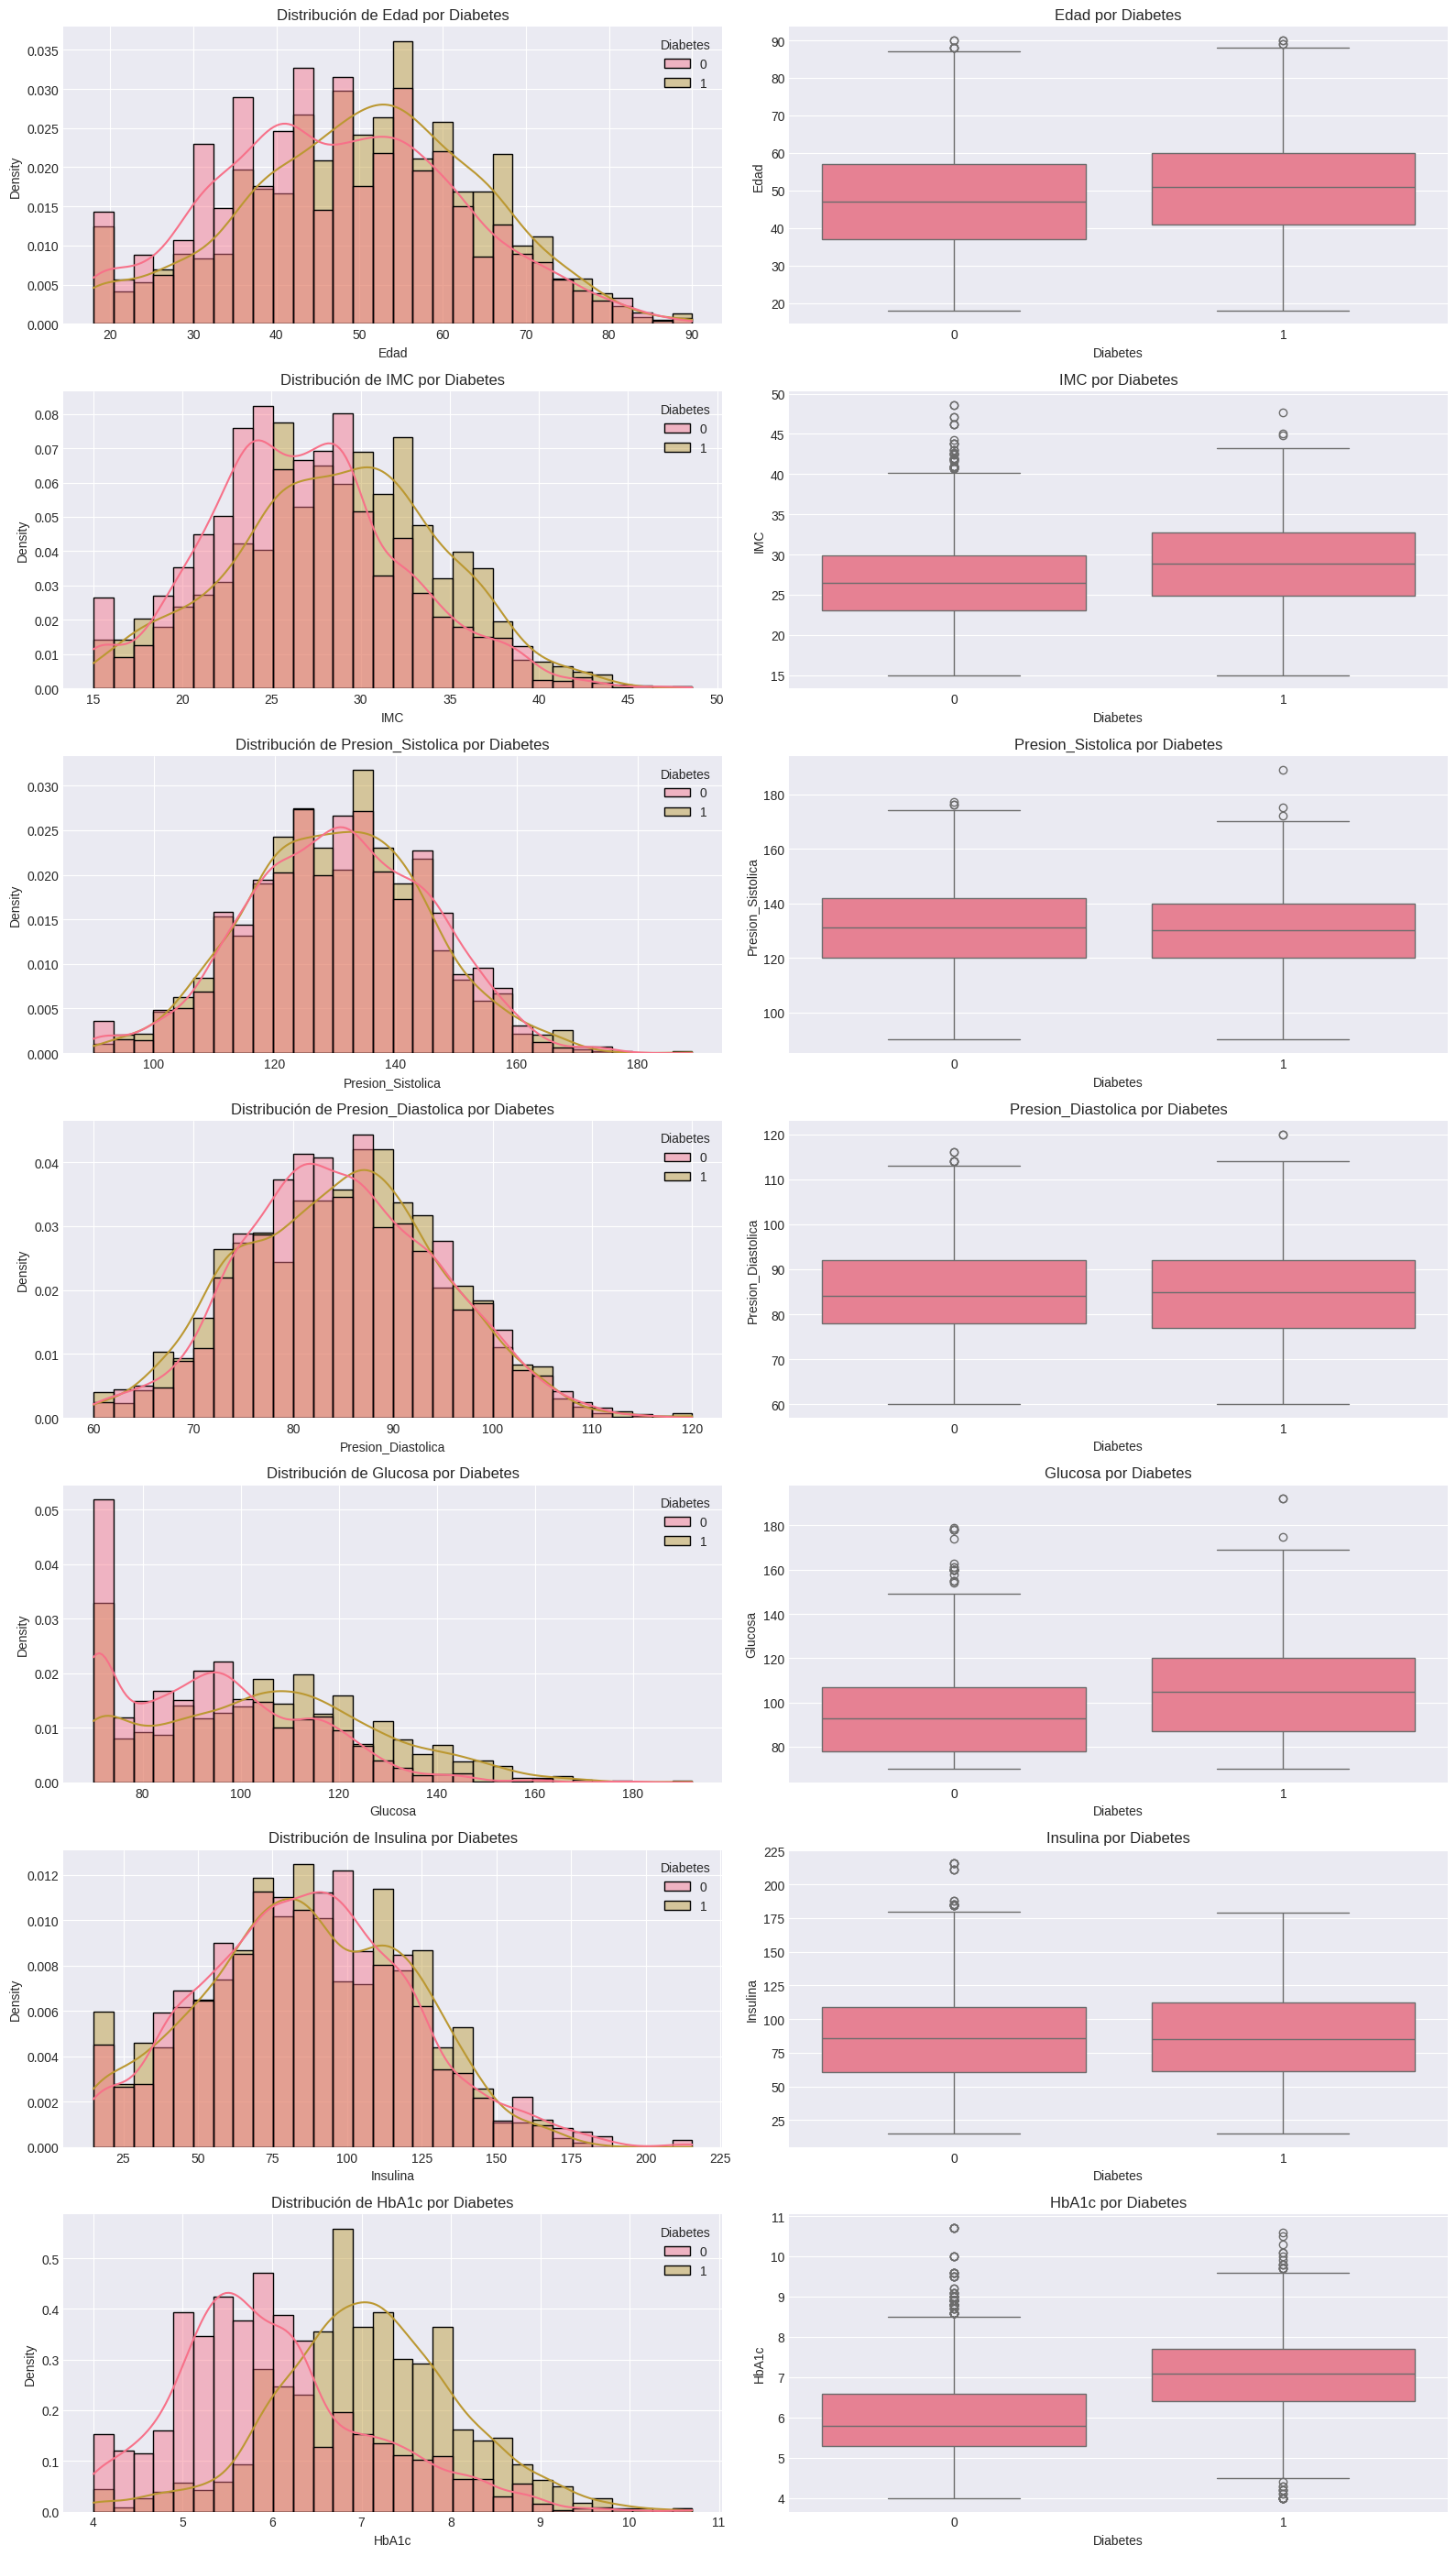

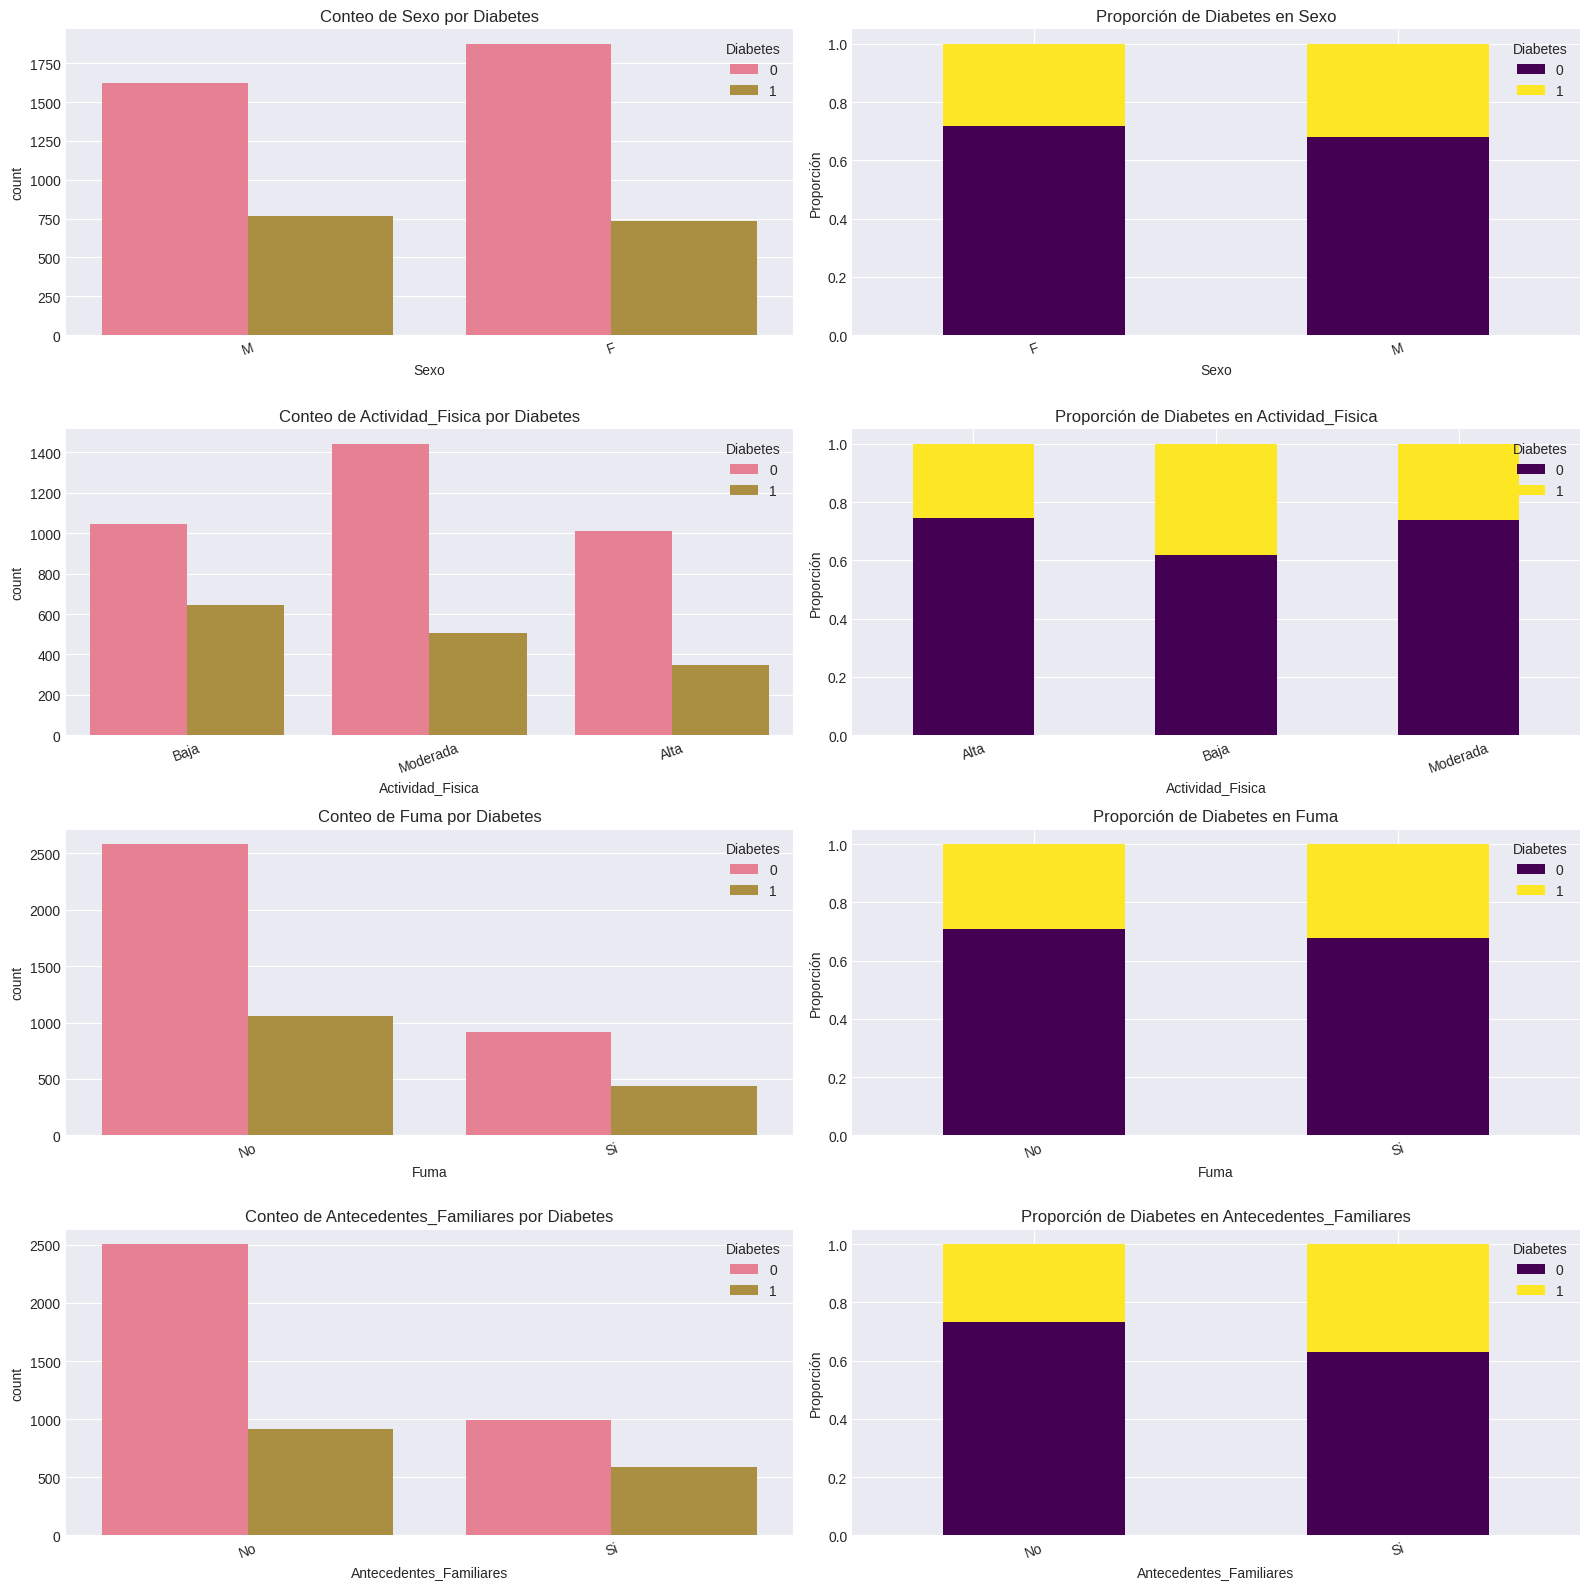

In [7]:
# análisis visual de la distribución y comportamiento de las variables categóricas y numéricas.

# Variables a graficar
num_cols = [c for c in numericas if c != 'Diabetes']
cat_cols = list(categoricas)

# -----------------------------
# 1) Variables numéricas
# -----------------------------
fig, axes = plt.subplots(len(num_cols), 2, figsize=(16, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Distribución por clase
    sns.histplot(
        data=df, x=col, hue='Diabetes', kde=True, bins=30,
        stat='density', common_norm=False, alpha=0.45, ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribución de {col} por Diabetes')

    # Comportamiento por clase
    sns.boxplot(data=df, x='Diabetes', y=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} por Diabetes')

plt.tight_layout()
plt.show()

# -----------------------------
# 2) Variables categóricas
# -----------------------------
fig, axes = plt.subplots(len(cat_cols), 2, figsize=(16, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    # Conteos absolutos
    sns.countplot(data=df, x=col, hue='Diabetes', ax=axes[i, 0])
    axes[i, 0].set_title(f'Conteo de {col} por Diabetes')
    axes[i, 0].tick_params(axis='x', rotation=20)

    # Proporciones por categoría
    prop = pd.crosstab(df[col], df['Diabetes'], normalize='index')
    prop.plot(kind='bar', stacked=True, ax=axes[i, 1], colormap='viridis')
    axes[i, 1].set_title(f'Proporción de Diabetes en {col}')
    axes[i, 1].set_ylabel('Proporción')
    axes[i, 1].tick_params(axis='x', rotation=20)
    axes[i, 1].legend(title='Diabetes')

plt.tight_layout()
plt.savefig('../images/eda_variables.png', dpi=300, bbox_inches='tight')
plt.show()


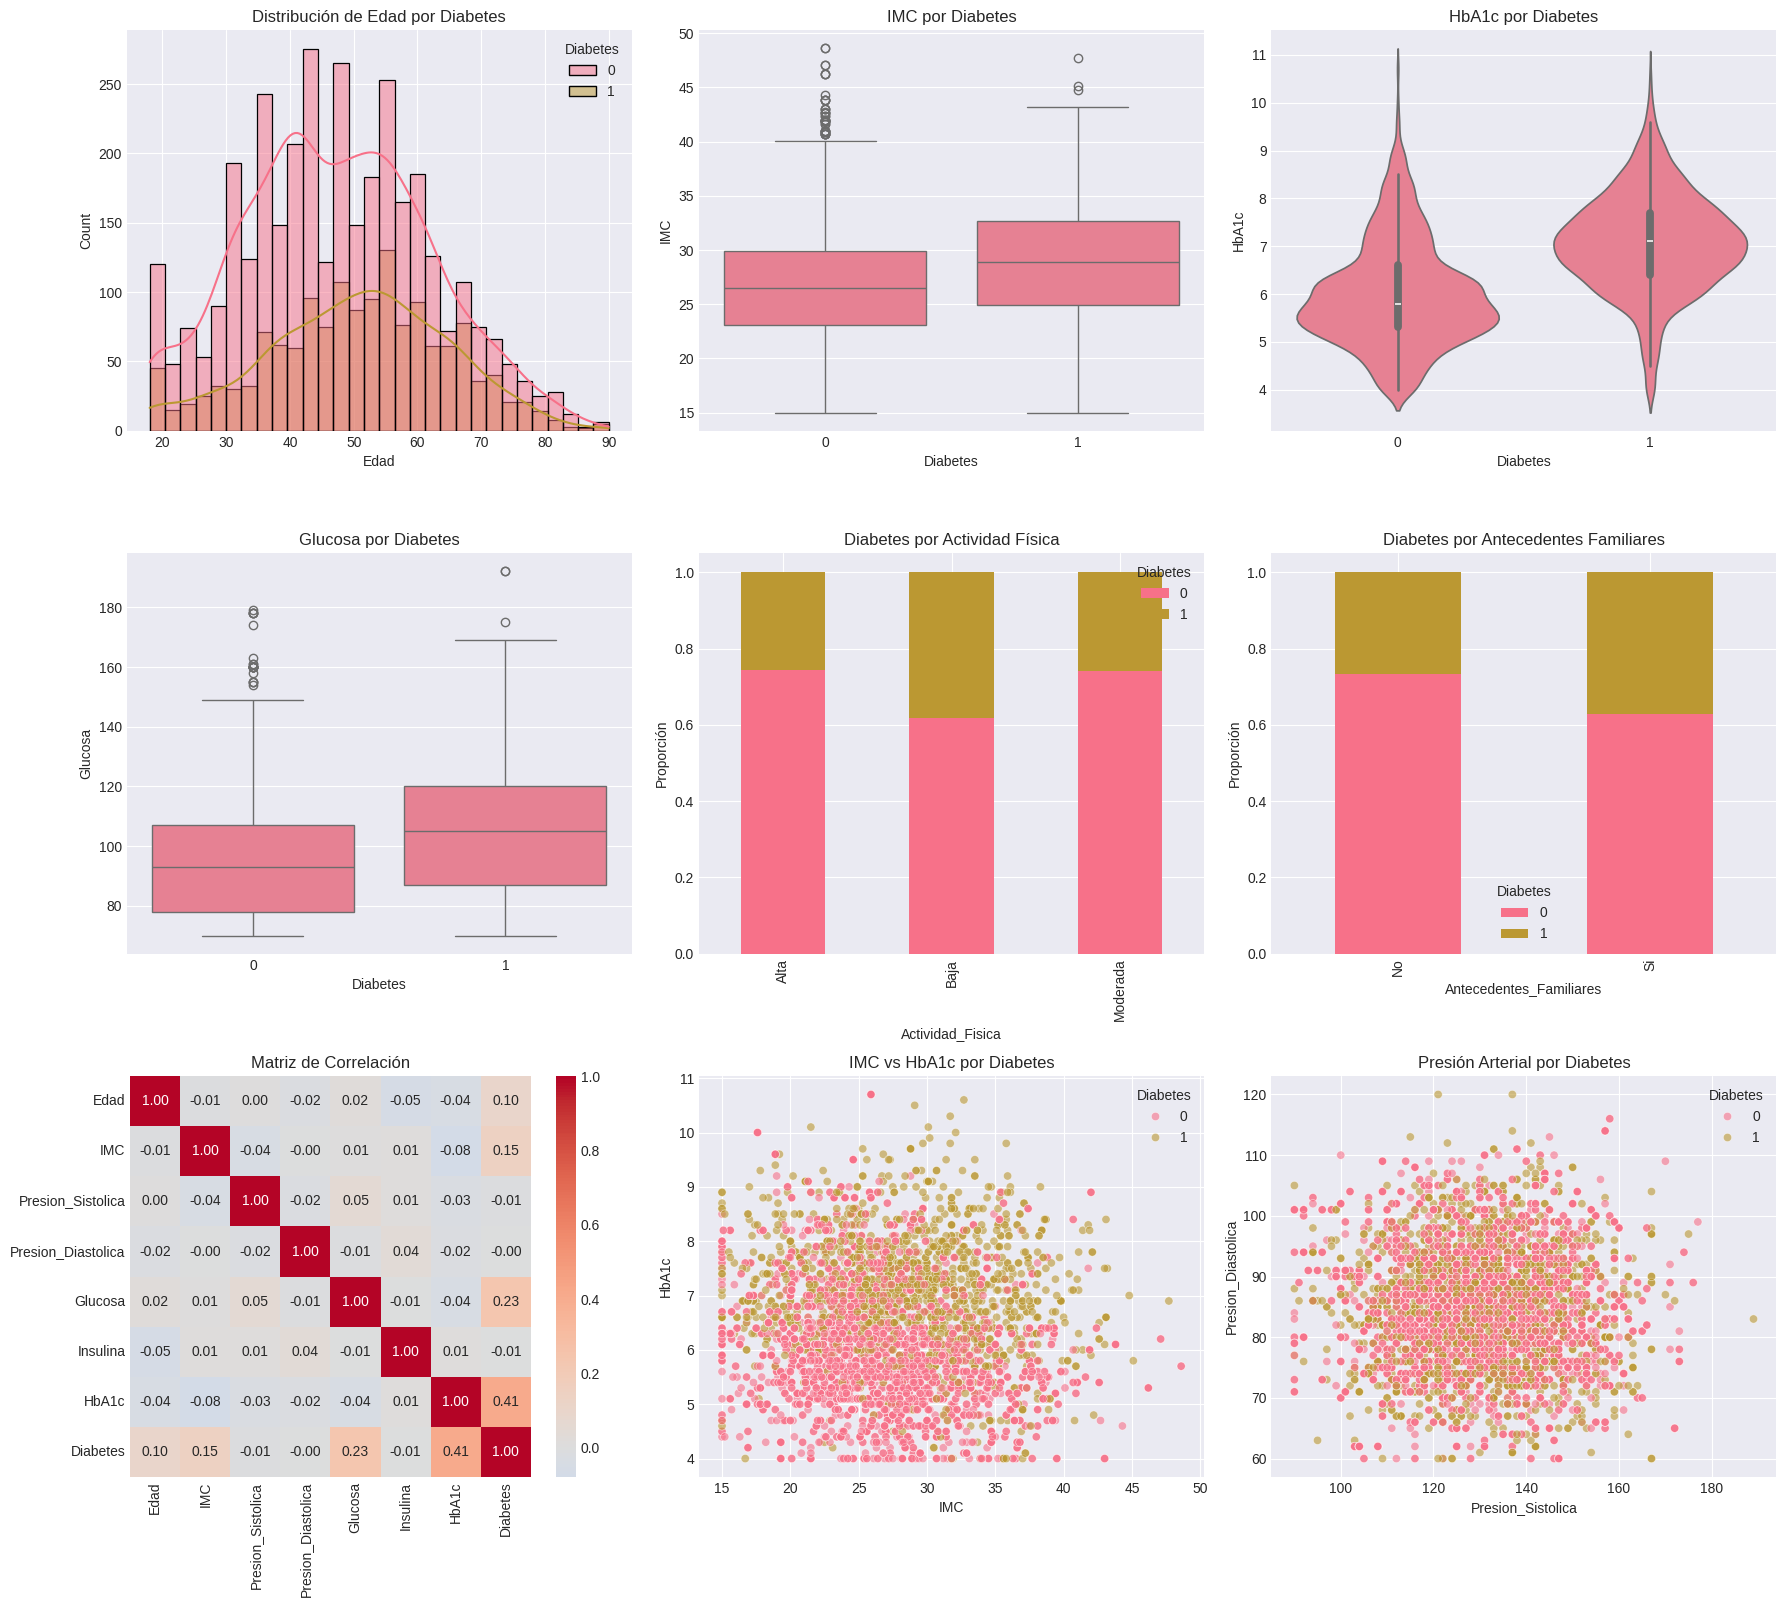

In [8]:

# Visualizaciones del EDA
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# 1. Distribución de Edad por Diabetes
sns.histplot(data=df, x='Edad', hue='Diabetes', kde=True, ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Distribución de Edad por Diabetes')

# 2. Distribución de IMC por Diabetes
sns.boxplot(data=df, x='Diabetes', y='IMC', ax=axes[0, 1])
axes[0, 1].set_title('IMC por Diabetes')

# 3. Distribución de HbA1c por Diabetes
sns.violinplot(data=df, x='Diabetes', y='HbA1c', ax=axes[0, 2])
axes[0, 2].set_title('HbA1c por Diabetes')

# 4. Distribución de Glucosa por Diabetes
sns.boxplot(data=df, x='Diabetes', y='Glucosa', ax=axes[1, 0])
axes[1, 0].set_title('Glucosa por Diabetes')

# 5. Diabetes por Actividad Física
pd.crosstab(df['Actividad_Fisica'], df['Diabetes'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('Diabetes por Actividad Física')
axes[1, 1].set_ylabel('Proporción')

# 6. Diabetes por Antecedentes Familiares
pd.crosstab(df['Antecedentes_Familiares'], df['Diabetes'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1, 2])
axes[1, 2].set_title('Diabetes por Antecedentes Familiares')
axes[1, 2].set_ylabel('Proporción')

# 7. Matriz de correlación (variables numéricas)
numericas = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numericas].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[2, 0])
axes[2, 0].set_title('Matriz de Correlación')

# 8. Relación IMC vs HbA1c por Diabetes
sns.scatterplot(data=df, x='IMC', y='HbA1c', hue='Diabetes', alpha=0.6, ax=axes[2, 1])
axes[2, 1].set_title('IMC vs HbA1c por Diabetes')

# 9. Presión arterial por Diabetes
sns.scatterplot(data=df, x='Presion_Sistolica', y='Presion_Diastolica', 
                hue='Diabetes', alpha=0.6, ax=axes[2, 2])
axes[2, 2].set_title('Presión Arterial por Diabetes')

plt.tight_layout()
plt.savefig('../images/eda_diabetes.png', dpi=300, bbox_inches='tight')
plt.show()